In [1]:
import numpy as np
import polars as pl
import os
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
#from run_stacking import *
from sklearn.metrics import accuracy_score

In [2]:
write_dir = "experiments/automl_oof_all_classifiers_shuffled/"

In [3]:
df = pl.read_parquet(f'{write_dir}/*.parquet')
df

dataset,model,run,oof_pred,oof_true,test_ensemble_pred,test_single_pred,test_true,classes
str,str,i64,list[list[f64]],list[str],list[list[f64]],list[list[f64]],list[str],list[str]
"""GestureMidAirD1""","""quant""",1,"[[0.775, 0.015, … 0.02], [0.67, 0.0, … 0.01], … [0.01, 0.005, … 0.96]]","[""1"", ""1"", … ""9""]","[[0.7985, 0.0035, … 0.0175], [0.8325, 0.0035, … 0.0315], … [0.0505, 0.0075, … 0.7555]]","[[0.85, 0.0, … 0.005], [0.855, 0.0, … 0.035], … [0.055, 0.01, … 0.74]]","[""1"", ""1"", … ""9""]","[""1"", ""10"", … ""9""]"
"""ProximalPhalanxTW""","""rocket""",4,"[[0.0, 1.0, … 0.0], [0.0, 1.0, … 0.0], … [0.0, 0.0, … 1.0]]","[""3"", ""3"", … ""8""]","[[0.7, 0.3, … 0.0], [0.0, 1.0, … 0.0], … [0.0, 0.0, … 1.0]]","[[1.0, 0.0, … 0.0], [0.0, 1.0, … 0.0], … [0.0, 0.0, … 1.0]]","[""3"", ""3"", … ""8""]","[""3"", ""4"", … ""8""]"
"""MixedShapesSmallTrain""","""downsample-0.5-multirockethydr…",2,"[[1.0, 0.0, … 0.0], [1.0, 0.0, … 0.0], … [0.0, 0.0, … 1.0]]","[""1"", ""1"", … ""5""]","[[1.0, 0.0, … 0.0], [1.0, 0.0, … 0.0], … [0.0, 0.0, … 1.0]]","[[1.0, 0.0, … 0.0], [1.0, 0.0, … 0.0], … [0.0, 0.0, … 1.0]]","[""1"", ""1"", … ""5""]","[""1"", ""2"", … ""5""]"
"""RefrigerationDevices""","""multirockethydra""",1,"[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], … [1.0, 0.0, 0.0]]","[""1"", ""1"", … ""3""]","[[0.9, 0.1, 0.0], [0.9, 0.1, 0.0], … [0.6, 0.4, 0.0]]","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], … [1.0, 0.0, 0.0]]","[""1"", ""1"", … ""3""]","[""1"", ""2"", ""3""]"
"""SonyAIBORobotSurface1""","""multirockethydra""",1,"[[1.0, 0.0], [1.0, 0.0], … [0.0, 1.0]]","[""1"", ""1"", … ""2""]","[[1.0, 0.0], [0.9, 0.1], … [0.0, 1.0]]","[[1.0, 0.0], [1.0, 0.0], … [0.0, 1.0]]","[""1"", ""1"", … ""2""]","[""1"", ""2""]"
…,…,…,…,…,…,…,…,…
"""MoteStrain""","""multirockethydra""",2,"[[1.0, 0.0], [1.0, 0.0], … [0.0, 1.0]]","[""1"", ""1"", … ""2""]","[[1.0, 0.0], [0.0, 1.0], … [0.0, 1.0]]","[[1.0, 0.0], [0.0, 1.0], … [0.0, 1.0]]","[""1"", ""1"", … ""2""]","[""1"", ""2""]"
"""StarLightCurves""","""quant""",0,"[[1.0, 0.0, 0.0], [0.69, 0.0, 0.31], … [0.07, 0.0, 0.93]]","[""1"", ""1"", … ""3""]","[[0.9995, 0.0, 0.0005], [0.985, 0.0, 0.015], … [0.0005, 0.0, 0.9995]]","[[0.995, 0.0, 0.005], [0.98, 0.0, 0.02], … [0.0, 0.0, 1.0]]","[""1"", ""1"", … ""3""]","[""1"", ""2"", ""3""]"
"""BirdChicken""","""catch22""",0,"[[0.95, 0.05], [0.94, 0.06], … [0.045, 0.955]]","[""1"", ""1"", … ""2""]","[[0.341, 0.659], [0.842, 0.158], … [0.0505, 0.9495]]","[[0.375, 0.625], [0.87, 0.13], … [0.06, 0.94]]","[""1"", ""1"", … ""2""]","[""1"", ""2""]"


In [4]:
def add_argmax_label(df: pl.DataFrame, label_col="label"):
    numeric_cols = [c for c in df.columns if df[c].dtype.is_numeric()]

    return df.with_columns(
        pl.struct(numeric_cols)
        .map_elements(lambda row: max(row, key=row.get))
        .alias(label_col)
    )

In [5]:
vall_accs = []
test_accs = []
test_accs_single = []
for row in df.iter_rows(named=True):
    val_pred = pl.DataFrame(np.array(row['oof_pred']), schema=row['classes']).pipe(add_argmax_label)
    val_true = row['oof_true']
    val_acc = accuracy_score(val_true, val_pred['label'])

    test_pred = pl.DataFrame(np.array(row['test_ensemble_pred']), schema=row['classes']).pipe(add_argmax_label)
    test_true = row['test_true']
    test_acc = accuracy_score(test_true, test_pred['label'])

    test_pred_single = pl.DataFrame(np.array(row['test_single_pred']), schema=row['classes']).pipe(add_argmax_label)
    test_acc_single = accuracy_score(test_true, test_pred_single['label'])


    vall_accs.append(val_acc)
    test_accs.append(test_acc)
    test_accs_single.append(test_acc_single)

df = df.with_columns(
    pl.Series(vall_accs).alias('val_acc'),
    pl.Series(test_accs).alias('test_acc'),
    pl.Series(test_accs_single).alias('test_acc_single'),
)

In [6]:
df.filter(pl.col('dataset') == 'DistalPhalanxOutlineCorrect').sort('model')

dataset,model,run,oof_pred,oof_true,test_ensemble_pred,test_single_pred,test_true,classes,val_acc,test_acc,test_acc_single
str,str,i64,list[list[f64]],list[str],list[list[f64]],list[list[f64]],list[str],list[str],f64,f64,f64
"""DistalPhalanxOutlineCorrect""","""catch22""",3,"[[0.445, 0.555], [0.825, 0.175], … [0.11, 0.89]]","[""0"", ""0"", … ""1""]","[[0.6085, 0.3915], [0.4295, 0.5705], … [0.02, 0.98]]","[[0.645, 0.355], [0.49, 0.51], … [0.03, 0.97]]","[""0"", ""0"", … ""1""]","[""0"", ""1""]",0.79,0.869565,0.880435
"""DistalPhalanxOutlineCorrect""","""catch22""",4,"[[0.455, 0.545], [0.86, 0.14], … [0.12, 0.88]]","[""0"", ""0"", … ""1""]","[[0.6025, 0.3975], [0.4345, 0.5655], … [0.027, 0.973]]","[[0.595, 0.405], [0.405, 0.595], … [0.025, 0.975]]","[""0"", ""0"", … ""1""]","[""0"", ""1""]",0.791667,0.865942,0.869565
"""DistalPhalanxOutlineCorrect""","""catch22""",1,"[[0.5, 0.5], [0.895, 0.105], … [0.13, 0.87]]","[""0"", ""0"", … ""1""]","[[0.621, 0.379], [0.434, 0.566], … [0.034, 0.966]]","[[0.59, 0.41], [0.405, 0.595], … [0.015, 0.985]]","[""0"", ""0"", … ""1""]","[""0"", ""1""]",0.8,0.865942,0.869565
"""DistalPhalanxOutlineCorrect""","""catch22""",0,"[[0.455, 0.545], [0.805, 0.195], … [0.065, 0.935]]","[""0"", ""0"", … ""1""]","[[0.6135, 0.3865], [0.443, 0.557], … [0.0245, 0.9755]]","[[0.635, 0.365], [0.385, 0.615], … [0.02, 0.98]]","[""0"", ""0"", … ""1""]","[""0"", ""1""]",0.786667,0.862319,0.858696
"""DistalPhalanxOutlineCorrect""","""catch22""",2,"[[0.525, 0.475], [0.845, 0.155], … [0.085, 0.915]]","[""0"", ""0"", … ""1""]","[[0.64, 0.36], [0.436, 0.564], … [0.021, 0.979]]","[[0.64, 0.36], [0.385, 0.615], … [0.005, 0.995]]","[""0"", ""0"", … ""1""]","[""0"", ""1""]",0.79,0.862319,0.880435
…,…,…,…,…,…,…,…,…,…,…,…
"""DistalPhalanxOutlineCorrect""","""quant""",3,"[[0.435, 0.565], [0.82, 0.18], … [0.095, 0.905]]","[""0"", ""0"", … ""1""]","[[0.6085, 0.3915], [0.397, 0.603], … [0.0705, 0.9295]]","[[0.64, 0.36], [0.42, 0.58], … [0.075, 0.925]]","[""0"", ""0"", … ""1""]","[""0"", ""1""]",0.818333,0.873188,0.869565
"""DistalPhalanxOutlineCorrect""","""rocket""",0,"[[0.0, 1.0], [1.0, 0.0], … [0.0, 1.0]]","[""0"", ""0"", … ""1""]","[[1.0, 0.0], [0.7, 0.3], … [0.0, 1.0]]","[[1.0, 0.0], [1.0, 0.0], … [0.0, 1.0]]","[""0"", ""0"", … ""1""]","[""0"", ""1""]",0.806667,0.851449,0.855072
"""DistalPhalanxOutlineCorrect""","""rocket""",1,"[[0.0, 1.0], [1.0, 0.0], … [0.0, 1.0]]","[""0"", ""0"", … ""1""]","[[1.0, 0.0], [0.2, 0.8], … [0.0, 1.0]]","[[1.0, 0.0], [0.0, 1.0], … [0.0, 1.0]]","[""0"", ""0"", … ""1""]","[""0"", ""1""]",0.818333,0.865942,0.865942


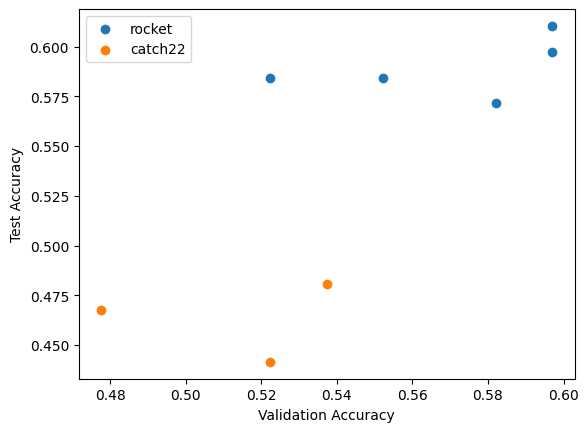

In [7]:
sdf = df.filter(pl.col('dataset') == 'DodgerLoopDay')
v1 = sdf.filter(pl.col('model') == 'rocket')
v2 = sdf.filter(pl.col('model') == 'catch22')
import matplotlib.pyplot as plt
plt.scatter(v1['val_acc'], v1['test_acc'], label='rocket')
plt.scatter(v2['val_acc'], v2['test_acc'], label='catch22')


plt.xlabel('Validation Accuracy')
plt.ylabel('Test Accuracy')
plt.legend()

In [8]:
df

dataset,model,run,oof_pred,oof_true,test_ensemble_pred,test_single_pred,test_true,classes,val_acc,test_acc,test_acc_single
str,str,i64,list[list[f64]],list[str],list[list[f64]],list[list[f64]],list[str],list[str],f64,f64,f64
"""GestureMidAirD1""","""quant""",1,"[[0.775, 0.015, … 0.02], [0.67, 0.0, … 0.01], … [0.01, 0.005, … 0.96]]","[""1"", ""1"", … ""9""]","[[0.7985, 0.0035, … 0.0175], [0.8325, 0.0035, … 0.0315], … [0.0505, 0.0075, … 0.7555]]","[[0.85, 0.0, … 0.005], [0.855, 0.0, … 0.035], … [0.055, 0.01, … 0.74]]","[""1"", ""1"", … ""9""]","[""1"", ""10"", … ""9""]",0.644231,0.715385,0.692308
"""ProximalPhalanxTW""","""rocket""",4,"[[0.0, 1.0, … 0.0], [0.0, 1.0, … 0.0], … [0.0, 0.0, … 1.0]]","[""3"", ""3"", … ""8""]","[[0.7, 0.3, … 0.0], [0.0, 1.0, … 0.0], … [0.0, 0.0, … 1.0]]","[[1.0, 0.0, … 0.0], [0.0, 1.0, … 0.0], … [0.0, 0.0, … 1.0]]","[""3"", ""3"", … ""8""]","[""3"", ""4"", … ""8""]",0.81,0.790244,0.790244
"""MixedShapesSmallTrain""","""downsample-0.5-multirockethydr…",2,"[[1.0, 0.0, … 0.0], [1.0, 0.0, … 0.0], … [0.0, 0.0, … 1.0]]","[""1"", ""1"", … ""5""]","[[1.0, 0.0, … 0.0], [1.0, 0.0, … 0.0], … [0.0, 0.0, … 1.0]]","[[1.0, 0.0, … 0.0], [1.0, 0.0, … 0.0], … [0.0, 0.0, … 1.0]]","[""1"", ""1"", … ""5""]","[""1"", ""2"", … ""5""]",0.92,0.964124,0.964124
"""RefrigerationDevices""","""multirockethydra""",1,"[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], … [1.0, 0.0, 0.0]]","[""1"", ""1"", … ""3""]","[[0.9, 0.1, 0.0], [0.9, 0.1, 0.0], … [0.6, 0.4, 0.0]]","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], … [1.0, 0.0, 0.0]]","[""1"", ""1"", … ""3""]","[""1"", ""2"", ""3""]",0.738667,0.757333,0.757333
"""SonyAIBORobotSurface1""","""multirockethydra""",1,"[[1.0, 0.0], [1.0, 0.0], … [0.0, 1.0]]","[""1"", ""1"", … ""2""]","[[1.0, 0.0], [0.9, 0.1], … [0.0, 1.0]]","[[1.0, 0.0], [1.0, 0.0], … [0.0, 1.0]]","[""1"", ""1"", … ""2""]","[""1"", ""2""]",0.95,0.978369,0.978369
…,…,…,…,…,…,…,…,…,…,…,…
"""MoteStrain""","""multirockethydra""",2,"[[1.0, 0.0], [1.0, 0.0], … [0.0, 1.0]]","[""1"", ""1"", … ""2""]","[[1.0, 0.0], [0.0, 1.0], … [0.0, 1.0]]","[[1.0, 0.0], [0.0, 1.0], … [0.0, 1.0]]","[""1"", ""1"", … ""2""]","[""1"", ""2""]",0.9,0.928115,0.926518
"""StarLightCurves""","""quant""",0,"[[1.0, 0.0, 0.0], [0.69, 0.0, 0.31], … [0.07, 0.0, 0.93]]","[""1"", ""1"", … ""3""]","[[0.9995, 0.0, 0.0005], [0.985, 0.0, 0.015], … [0.0005, 0.0, 0.9995]]","[[0.995, 0.0, 0.005], [0.98, 0.0, 0.02], … [0.0, 0.0, 1.0]]","[""1"", ""1"", … ""3""]","[""1"", ""2"", ""3""]",0.972,0.981909,0.982637
"""BirdChicken""","""catch22""",0,"[[0.95, 0.05], [0.94, 0.06], … [0.045, 0.955]]","[""1"", ""1"", … ""2""]","[[0.341, 0.659], [0.842, 0.158], … [0.0505, 0.9495]]","[[0.375, 0.625], [0.87, 0.13], … [0.06, 0.94]]","[""1"", ""1"", … ""2""]","[""1"", ""2""]",0.95,0.8,0.8


In [9]:
df.pivot(values='test_acc', index='dataset', on='model', aggregate_function='mean').sort('dataset')

dataset,quant,rocket,downsample-0.5-multirockethydra,multirockethydra,catch22
str,f64,f64,f64,f64,f64
"""ACSF1""",0.835,0.806667,0.824,0.81,0.735
"""Adiac""",0.807161,0.789003,0.822251,0.831202,0.677749
"""AllGestureWiimoteX""",0.6825,0.741714,0.760357,0.766,0.635
"""AllGestureWiimoteY""",0.698571,0.77,0.796429,0.793143,0.6975
"""AllGestureWiimoteZ""",0.68,0.706667,0.732143,0.731429,0.675143
…,…,…,…,…,…
"""Wine""",0.888889,0.981481,1.0,1.0,0.771605
"""WordSynonyms""",0.693182,0.768025,0.783699,0.782915,0.536573
"""Worms""",0.753247,0.707792,0.781818,0.757576,0.735065


In [10]:
df.pivot(values='val_acc', index='dataset', on='model', aggregate_function='mean').sort('dataset')

dataset,quant,rocket,downsample-0.5-multirockethydra,multirockethydra,catch22
str,f64,f64,f64,f64,f64
"""ACSF1""",0.7875,0.803333,0.844,0.843333,0.7625
"""Adiac""",0.821538,0.764103,0.827564,0.844444,0.730769
"""AllGestureWiimoteX""",0.6125,0.669333,0.685,0.699333,0.581667
"""AllGestureWiimoteY""",0.660833,0.705,0.753333,0.740667,0.5875
"""AllGestureWiimoteZ""",0.662667,0.72,0.713333,0.7125,0.618667
…,…,…,…,…,…
"""Wine""",0.926316,0.929825,0.922807,0.921053,0.678363
"""WordSynonyms""",0.679775,0.758052,0.773408,0.777154,0.55181
"""Worms""",0.736188,0.686464,0.711602,0.723757,0.674033


In [11]:
model_subset = ['rocket', 'quant', 'catch22', 'multirockethydra']

In [12]:
vdf = df.pivot(values='val_acc', index='dataset', on='model', aggregate_function='mean').sort('dataset').select(['dataset'] + model_subset).drop_nulls()
vdf

dataset,rocket,quant,catch22,multirockethydra
str,f64,f64,f64,f64
"""ACSF1""",0.803333,0.7875,0.7625,0.843333
"""Adiac""",0.764103,0.821538,0.730769,0.844444
"""AllGestureWiimoteX""",0.669333,0.6125,0.581667,0.699333
"""AllGestureWiimoteY""",0.705,0.660833,0.5875,0.740667
"""AllGestureWiimoteZ""",0.72,0.662667,0.618667,0.7125
…,…,…,…,…
"""Wine""",0.929825,0.926316,0.678363,0.921053
"""WordSynonyms""",0.758052,0.679775,0.55181,0.777154
"""Worms""",0.686464,0.736188,0.674033,0.723757


In [13]:
tdf = df.pivot(values='test_acc_single', index='dataset', on='model', aggregate_function='mean').sort('dataset').select(['dataset'] + model_subset).drop_nulls()
tdf

dataset,rocket,quant,catch22,multirockethydra
str,f64,f64,f64,f64
"""ACSF1""",0.806667,0.8325,0.74,0.803333
"""Adiac""",0.790281,0.807673,0.678602,0.827792
"""AllGestureWiimoteX""",0.734,0.678571,0.636786,0.759714
"""AllGestureWiimoteY""",0.770357,0.7025,0.697143,0.785143
"""AllGestureWiimoteZ""",0.70381,0.681143,0.665429,0.730714
…,…,…,…,…
"""Wine""",0.981481,0.892593,0.802469,1.0
"""WordSynonyms""",0.767085,0.698668,0.533438,0.782524
"""Worms""",0.704545,0.775974,0.74026,0.766234


In [14]:
j = vdf.join(tdf, on='dataset', suffix='_test')
j

dataset,rocket,quant,catch22,multirockethydra,rocket_test,quant_test,catch22_test,multirockethydra_test
str,f64,f64,f64,f64,f64,f64,f64,f64
"""ACSF1""",0.803333,0.7875,0.7625,0.843333,0.806667,0.8325,0.74,0.803333
"""Adiac""",0.764103,0.821538,0.730769,0.844444,0.790281,0.807673,0.678602,0.827792
"""AllGestureWiimoteX""",0.669333,0.6125,0.581667,0.699333,0.734,0.678571,0.636786,0.759714
"""AllGestureWiimoteY""",0.705,0.660833,0.5875,0.740667,0.770357,0.7025,0.697143,0.785143
"""AllGestureWiimoteZ""",0.72,0.662667,0.618667,0.7125,0.70381,0.681143,0.665429,0.730714
…,…,…,…,…,…,…,…,…
"""Wine""",0.929825,0.926316,0.678363,0.921053,0.981481,0.892593,0.802469,1.0
"""WordSynonyms""",0.758052,0.679775,0.55181,0.777154,0.767085,0.698668,0.533438,0.782524
"""Worms""",0.686464,0.736188,0.674033,0.723757,0.704545,0.775974,0.74026,0.766234


In [15]:
stat_data = []
for row in j.iter_rows(named=True):
    v1 = [row[model] for model in model_subset]
    v2 = [row[f'{model}_test'] for model in model_subset]
    # ocmpute sperman
    from scipy import stats
    res = stats.spearmanr(v1, v2).statistic
    #print(row['dataset'], res)
    stat_data.append({
        'dataset': row['dataset'],
        'spearmanr': res
    })
stat_df = pl.DataFrame(stat_data).sort('spearmanr')

/tmp/ipykernel_968421/4289782378.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  res = stats.spearmanr(v1, v2).statistic


In [16]:
stat_df

dataset,spearmanr
str,f64
"""CBF""",-0.774597
"""Mallat""",-0.6
"""Lightning2""",-0.4
"""MiddlePhalanxOutlineAgeGroup""",-0.2
"""WormsTwoClass""",-0.2
…,…
"""WordSynonyms""",1.0
"""Yoga""",1.0
"""Coffee""",NaN


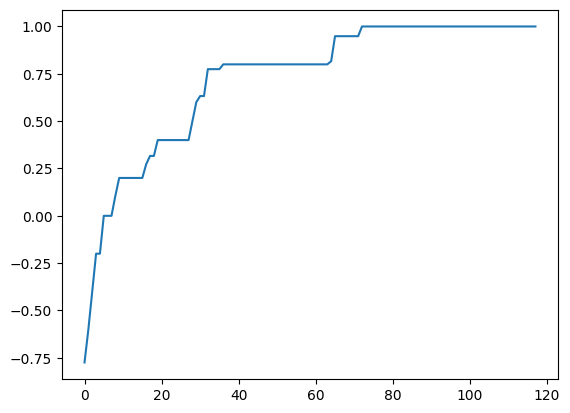

In [17]:
plt.plot(stat_df['spearmanr'])